In [1]:
import sys
print(sys.executable)

import tensorflow as tf
import numpy as np
import pandas as pd
import wfdb
import os
import ast
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

print(tf.__version__)
print(np.__version__)
print(pd.__version__)
print(wfdb.__version__)


C:\Users\aaron\anaconda3\envs\ecg2\python.exe

2.15.0
1.26.4
2.3.3
4.2.0


In [2]:
ptb_root = r"C:\Users\aaron\Downloads\458\498-Capstone\PTB-XL"
ptb_df = pd.read_csv(os.path.join(ptb_root, "ptbxl_database.csv"))

def load_ptbxl_record(ptb_root, filename_hr):
    record_path = os.path.join(ptb_root, filename_hr)
    record = wfdb.rdrecord(record_path)
    ecg = record.p_signal.T                # (12, 5000)
    return ecg.astype(np.float16)          # lower memory

def process_row(fname, scp_str):
    signal = load_ptbxl_record(ptb_root, fname)
    scp_dict = ast.literal_eval(scp_str)
    label = "PTB-" + list(scp_dict.keys())[0]
    return signal, label

results = [process_row(f, s) for f, s in zip(ptb_df["filename_hr"], ptb_df["scp_codes"])]
X_ptb, y_ptb = zip(*results)

X_ptb = np.array(X_ptb)
y_ptb = np.array(y_ptb)

In [3]:
def load_ludb(base_path, csv_file, label_col="Rhythms", max_samples=50):
    df = pd.read_csv(csv_file)
    df = df.iloc[:max_samples]

    X_list, y_list = [], []

    for _, row in df.iterrows():
        rec_id = row["ID"]
        record_path = os.path.join(base_path, str(rec_id))

        try:
            record = wfdb.rdrecord(record_path)
            signal = record.p_signal.astype(np.float16).T
            X_list.append(signal)
            y_list.append(str(row[label_col]))
        except Exception as e:
            print(f"⚠️ Error loading LUDB record {rec_id}: {e}")

    X = np.stack(X_list, axis=0)
    y = np.array(y_list)
    return X, y

ludb_signal_path = r"C:\Users\aaron\Downloads\458\498-Capstone\ludb\ludb"
ludb_csv_path = r"C:\Users\aaron\Downloads\458\498-Capstone\ludb\ludb.csv"

X_ludb, y_ludb = load_ludb(ludb_signal_path, ludb_csv_path, label_col="Rhythms", max_samples=50)



In [4]:
def combine_datasets(X1, y1, X2, y2, max_len=None):
    if max_len is None:
        max_len = min(X1.shape[2], X2.shape[2])  # trim safely

    X1_trim = X1[:, :, :max_len]
    X2_trim = X2[:, :, :max_len]

    X1_trim = X1_trim[..., np.newaxis]
    X2_trim = X2_trim[..., np.newaxis]

    X_comb = np.concatenate([X1_trim, X2_trim], axis=0)
    y_comb = np.concatenate([y1, y2], axis=0)
    return X_comb, y_comb

X_comb, y_comb = combine_datasets(X_ludb, y_ludb, X_ptb, y_ptb)

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y_comb)

# Remove labels that occur <2 times
unique, counts = np.unique(y_encoded, return_counts=True)
valid_labels = unique[counts >= 2]

mask = np.isin(y_encoded, valid_labels)

X_clean = X_comb[mask]
y_clean = y_encoded[mask]

print("Before filtering:", len(y_encoded))
print("After filtering:", len(y_clean))
print("Removed:", len(y_encoded) - len(y_clean))


Before filtering: 21849
After filtering: 21846
Removed: 3


In [6]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Dropout, Flatten,
                                     Dense, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping


In [7]:


X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y_clean,
    train_size=0.4,
    test_size=0.15,
    random_state=42,
    stratify=y_clean
)

In [8]:
le_final = LabelEncoder()
y_train = le_final.fit_transform(y_train)
y_test = le_final.transform(y_test)

num_classes = len(le_final.classes_)
print("FINAL num_classes:", num_classes)
print("FINAL y_train max:", y_train.max())
print("FINAL y_test max:", y_test.max())

FINAL num_classes: 52
FINAL y_train max: 51
FINAL y_test max: 51


In [9]:
# --- Ensure float16 for memory efficiency ---
X_train = X_train.astype(np.float16)
X_test = X_test.astype(np.float16)

# --- Remove singleton channel dimension ---
X_train = X_train.squeeze(-1)  # now (n_samples, 12, 5000)
X_test = X_test.squeeze(-1)

# --- Transpose to (samples, timesteps, channels) ---
X_train = np.transpose(X_train, (0, 2, 1))  # (n_samples, 5000, 12)
X_test = np.transpose(X_test, (0, 2, 1))    # (n_samples, 5000, 12)

# --- Categorical labels ---
num_classes = len(np.unique(y_train))
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes)
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes)

# --- Dataset pipeline ---
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train_cat)).batch(64).prefetch(tf.data.AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test_cat)).batch(64).prefetch(tf.data.AUTOTUNE)



In [10]:

# --- 1D CNN ---
model = Sequential([
    Conv1D(32, kernel_size=7, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    BatchNormalization(),
    MaxPooling1D(4),  # reduced pooling factor to avoid too small output

    Conv1D(64, kernel_size=5, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(4),

    Conv1D(128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),

    Dropout(0.5),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()





Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 4994, 32)          2720      
                                                                 
 batch_normalization (Batch  (None, 4994, 32)          128       
 Normalization)                                                  
                                                                 
 max_pooling1d (MaxPooling1  (None, 1248, 32)          0         
 D)                                                              
                                                                 
 conv1d_1 (Conv1D)           (None, 1244, 64)          10304     
                                                                 
 batch_normalization_1 (Bat  (None, 1244, 64)          256       
 chNormalization)                                                
                                                     

In [11]:


# --- Create validation split manually ---
val_size = int(0.2 * len(X_train))

X_val = X_train[:val_size]
y_val = y_train_cat[:val_size]

X_train2 = X_train[val_size:]
y_train2 = y_train_cat[val_size:]

train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train2, y_train2))
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
)







In [12]:
# --- Train ---
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=2
)


model.save("498_1DCNN.keras")

Epoch 1/15


110/110 - 57s - loss: 3.1070 - accuracy: 0.3821 - val_loss: 5.9897 - val_accuracy: 0.4350 - 57s/epoch - 521ms/step
Epoch 2/15
110/110 - 48s - loss: 2.2451 - accuracy: 0.4673 - val_loss: 7.7789 - val_accuracy: 0.4390 - 48s/epoch - 439ms/step
Epoch 3/15
110/110 - 43s - loss: 1.9701 - accuracy: 0.5075 - val_loss: 6.8875 - val_accuracy: 0.4574 - 43s/epoch - 394ms/step
Epoch 4/15
110/110 - 45s - loss: 1.7682 - accuracy: 0.5355 - val_loss: 2.9620 - val_accuracy: 0.5157 - 45s/epoch - 406ms/step
Epoch 5/15
110/110 - 44s - loss: 1.6220 - accuracy: 0.5622 - val_loss: 2.2200 - val_accuracy: 0.5564 - 44s/epoch - 404ms/step
Epoch 6/15
110/110 - 43s - loss: 1.4806 - accuracy: 0.5882 - val_loss: 2.0929 - val_accuracy: 0.5592 - 43s/epoch - 393ms/step
Epoch 7/15
110/110 - 42s - loss: 1.3777 - accuracy: 0.6088 - val_loss: 1.9464 - val_accuracy: 0.5627 - 42s/epoch - 380ms/step
Epoch 8/15
110/110 - 42s - loss: 1.2627 - accuracy: 0.6241 - val_loss: 1.9790 - val_accuracy: 0.5764 - 42s/epoch - 3

✅ Test Accuracy: 0.5462
52/52 [==============================] - 3s 60ms/step


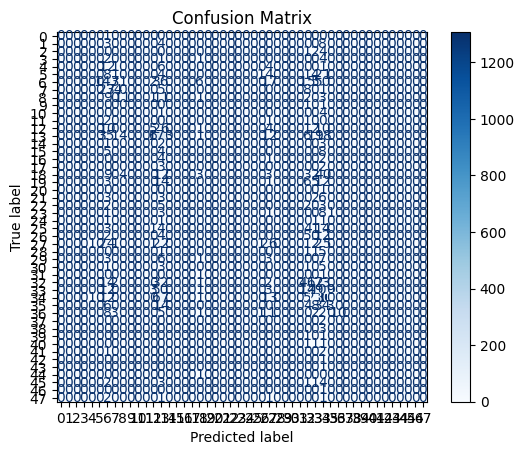

C:\Users\aaron\anaconda3\envs\ecg2\lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
C:\Users\aaron\anaconda3\envs\ecg2\lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
C:\Users\aaron\anaconda3\envs\ecg2\lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
C:\Users\aaron\anaconda3\envs\ecg2\lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


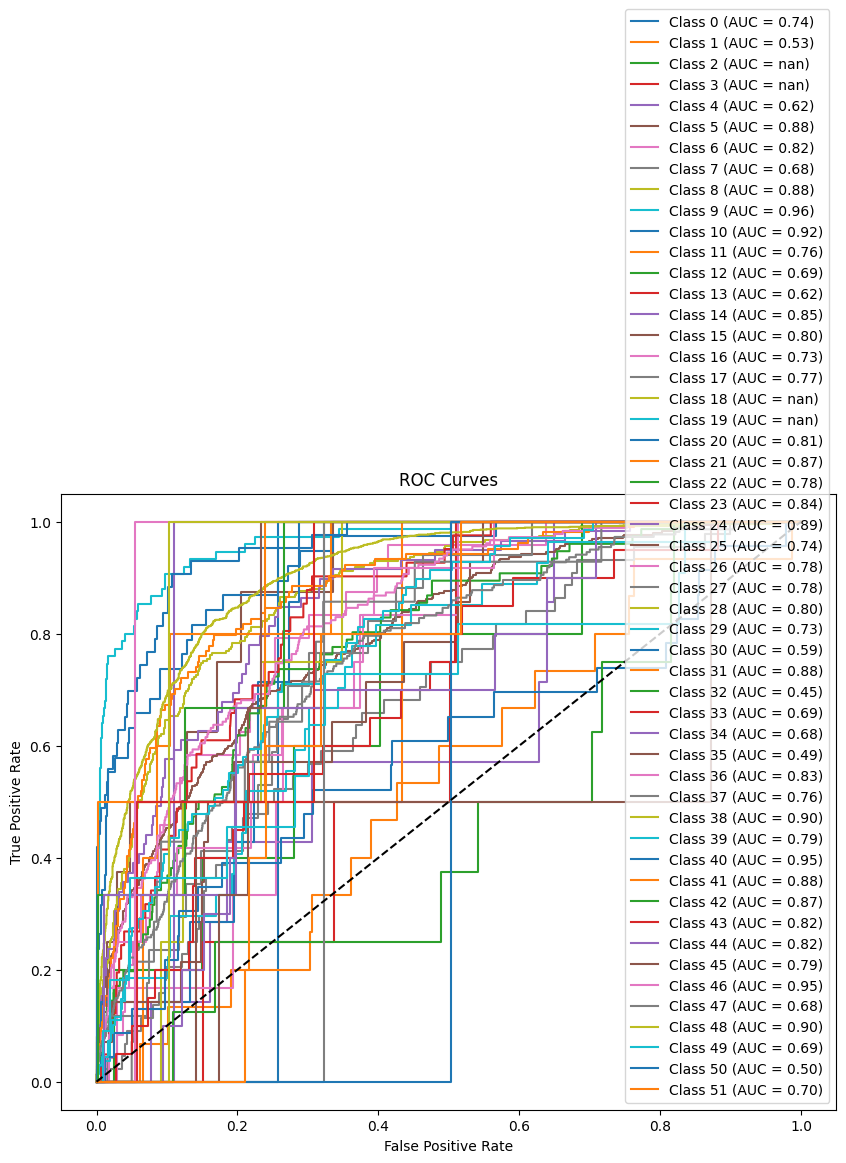

C:\Users\aaron\anaconda3\envs\ecg2\lib\site-packages\sklearn\metrics\_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
C:\Users\aaron\anaconda3\envs\ecg2\lib\site-packages\sklearn\metrics\_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
C:\Users\aaron\anaconda3\envs\ecg2\lib\site-packages\sklearn\metrics\_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
C:\Users\aaron\anaconda3\envs\ecg2\lib\site-packages\sklearn\metrics\_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
C:\Users\aaron\anaconda3\envs\ecg2\lib\site-packages\sklearn\metrics\_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
C:\Users\aaron\anaconda3\envs\ecg2\

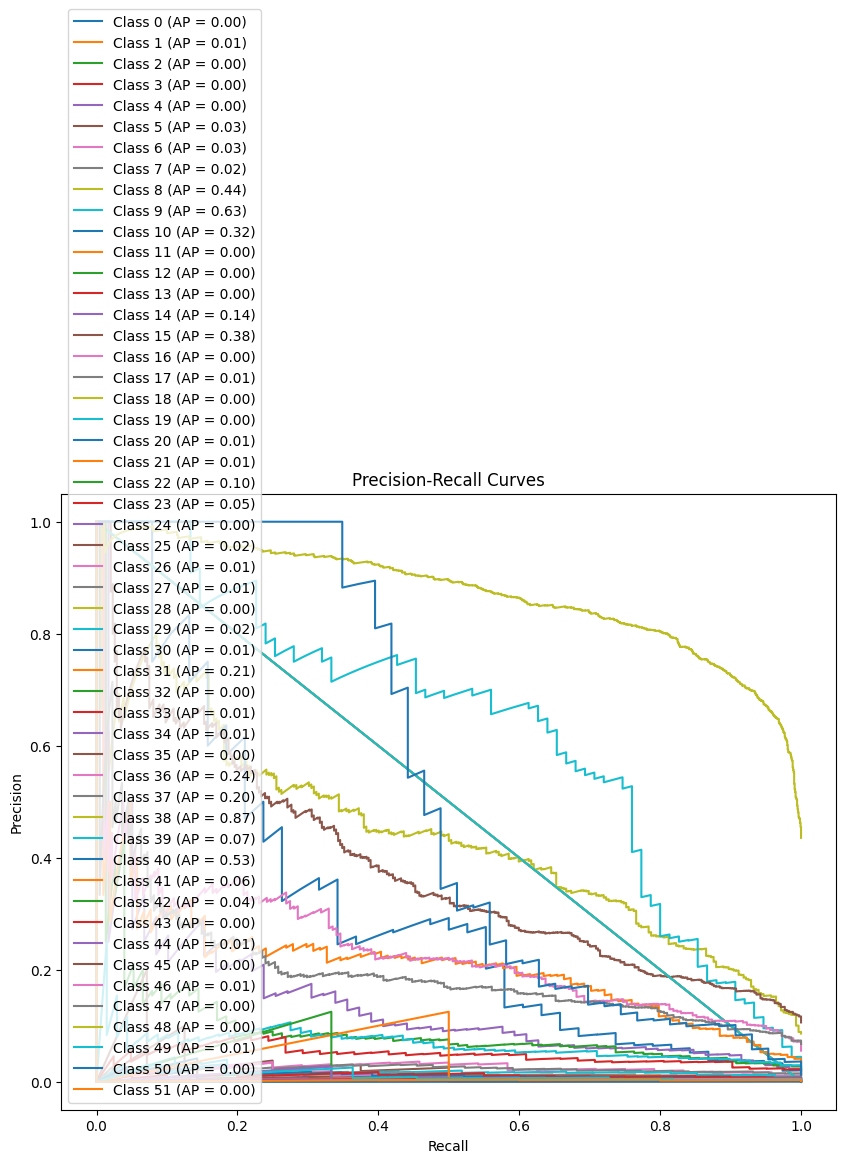

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt


# --- Evaluate ---
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"✅ Test Accuracy: {test_acc:.4f}")

# --- Predictions ---
y_pred_prob = model.predict(X_test, batch_size=64)
y_pred = np.argmax(y_pred_prob, axis=1)

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# --- ROC curves ---
y_test_bin = label_binarize(y_test, classes=np.arange(num_classes))
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot per-class ROC
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.show()

# --- Precision-Recall curves ---
precision = dict()
recall = dict()
average_precision = dict()
for i in range(num_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_pred_prob[:, i])
    average_precision[i] = average_precision_score(y_test_bin[:, i], y_pred_prob[:, i])

# Plot per-class PR curve
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    plt.plot(recall[i], precision[i], label=f"Class {i} (AP = {average_precision[i]:.2f})")
plt.title("Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc='lower left')
plt.show()

In [14]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Activation, Add, GlobalAveragePooling1D

def residual_block(x, filters, kernel_size, stride=1, dropout_rate=0.1):
    shortcut = x

    # First conv
    x = Conv1D(filters, kernel_size, strides=stride, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    # Second conv
    x = Conv1D(filters, kernel_size, strides=1, padding="same")(x)
    x = BatchNormalization()(x)

    # Match dimensions if needed
    if shortcut.shape[-1] != filters or stride != 1:
        shortcut = Conv1D(filters, 1, strides=stride, padding="same")(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = Activation("relu")(x)

    if dropout_rate > 0:
        x = Dropout(dropout_rate)(x)

    return x


def build_strong_1dcnn(input_shape, num_classes):
    inp = Input(shape=input_shape)

    # Initial large receptive-field conv
    x = Conv1D(64, kernel_size=15, padding="same", activation="relu")(inp)
    x = BatchNormalization()(x)

    # Residual stacks
    x = residual_block(x, filters=64, kernel_size=7, dropout_rate=0.1)
    x = residual_block(x, filters=128, kernel_size=5, stride=2, dropout_rate=0.1)
    x = residual_block(x, filters=128, kernel_size=5, dropout_rate=0.1)
    x = residual_block(x, filters=256, kernel_size=3, stride=2, dropout_rate=0.1)
    x = residual_block(x, filters=256, kernel_size=3, dropout_rate=0.1)

    # Global pooling instead of Flatten
    x = GlobalAveragePooling1D()(x)

    # Dense classifier
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.4)(x)

    out = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=inp, outputs=out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# Build model
input_shape = (3000, 12)   # (timesteps, channels)
model = build_strong_1dcnn(input_shape, num_classes)

model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 3000, 12)]           0         []                            
                                                                                                  
 conv1d_3 (Conv1D)           (None, 3000, 64)             11584     ['input_1[0][0]']             
                                                                                                  
 batch_normalization_3 (Bat  (None, 3000, 64)             256       ['conv1d_3[0][0]']            
 chNormalization)                                                                                 
                                                                                                  
 conv1d_4 (Conv1D)           (None, 3000, 64)             28736     ['batch_normalization_3[0]

In [16]:
X_train_short = X_train[:, :3000, :]
X_test_short  = X_test[:, :3000, :]


history = model.fit(
    X_train_short,
    y_train_cat,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
    ],
    verbose=2
)


Epoch 1/20
246/246 - 771s - loss: 1.9540 - accuracy: 0.5128 - val_loss: 2.0426 - val_accuracy: 0.4931 - 771s/epoch - 3s/step
Epoch 2/20
246/246 - 736s - loss: 1.6740 - accuracy: 0.5725 - val_loss: 1.6855 - val_accuracy: 0.5423 - 736s/epoch - 3s/step
Epoch 3/20
246/246 - 778s - loss: 1.5538 - accuracy: 0.5969 - val_loss: 1.5813 - val_accuracy: 0.5938 - 778s/epoch - 3s/step
Epoch 4/20
246/246 - 762s - loss: 1.4897 - accuracy: 0.6055 - val_loss: 1.5029 - val_accuracy: 0.5973 - 762s/epoch - 3s/step
Epoch 5/20
246/246 - 766s - loss: 1.4318 - accuracy: 0.6202 - val_loss: 1.5741 - val_accuracy: 0.5778 - 766s/epoch - 3s/step
Epoch 6/20
246/246 - 741s - loss: 1.3899 - accuracy: 0.6237 - val_loss: 1.5726 - val_accuracy: 0.6178 - 741s/epoch - 3s/step
Epoch 7/20
246/246 - 742s - loss: 1.3523 - accuracy: 0.6392 - val_loss: 1.4119 - val_accuracy: 0.6270 - 742s/epoch - 3s/step
Epoch 8/20
246/246 - 751s - loss: 1.3110 - accuracy: 0.6414 - val_loss: 1.3619 - val_accuracy: 0.6110 - 751s/epoch - 3s/step



Test Accuracy: 0.6624962091445923
103/103 [==============================] - 61s 527ms/step


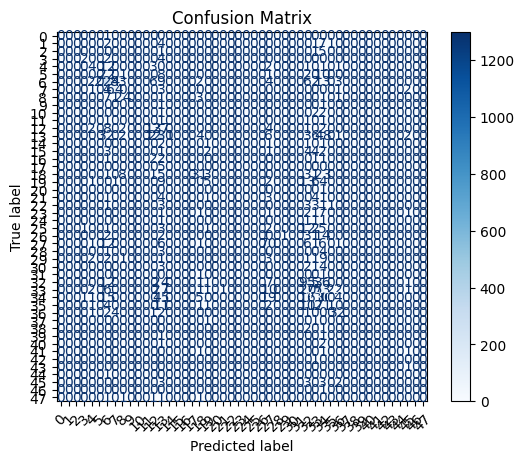

C:\Users\aaron\anaconda3\envs\ecg2\lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
C:\Users\aaron\anaconda3\envs\ecg2\lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
C:\Users\aaron\anaconda3\envs\ecg2\lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
C:\Users\aaron\anaconda3\envs\ecg2\lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


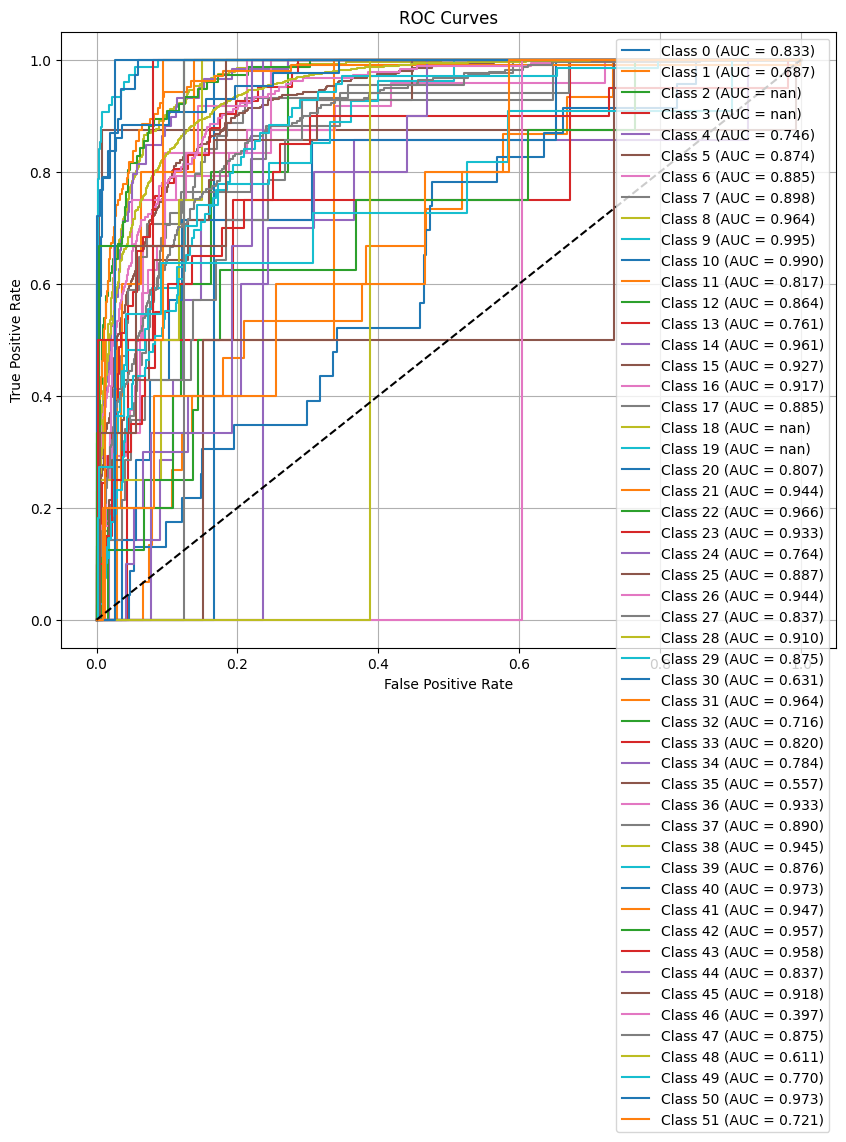

C:\Users\aaron\anaconda3\envs\ecg2\lib\site-packages\sklearn\metrics\_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
C:\Users\aaron\anaconda3\envs\ecg2\lib\site-packages\sklearn\metrics\_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
C:\Users\aaron\anaconda3\envs\ecg2\lib\site-packages\sklearn\metrics\_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
C:\Users\aaron\anaconda3\envs\ecg2\lib\site-packages\sklearn\metrics\_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
C:\Users\aaron\anaconda3\envs\ecg2\lib\site-packages\sklearn\metrics\_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
C:\Users\aaron\anaconda3\envs\ecg2\

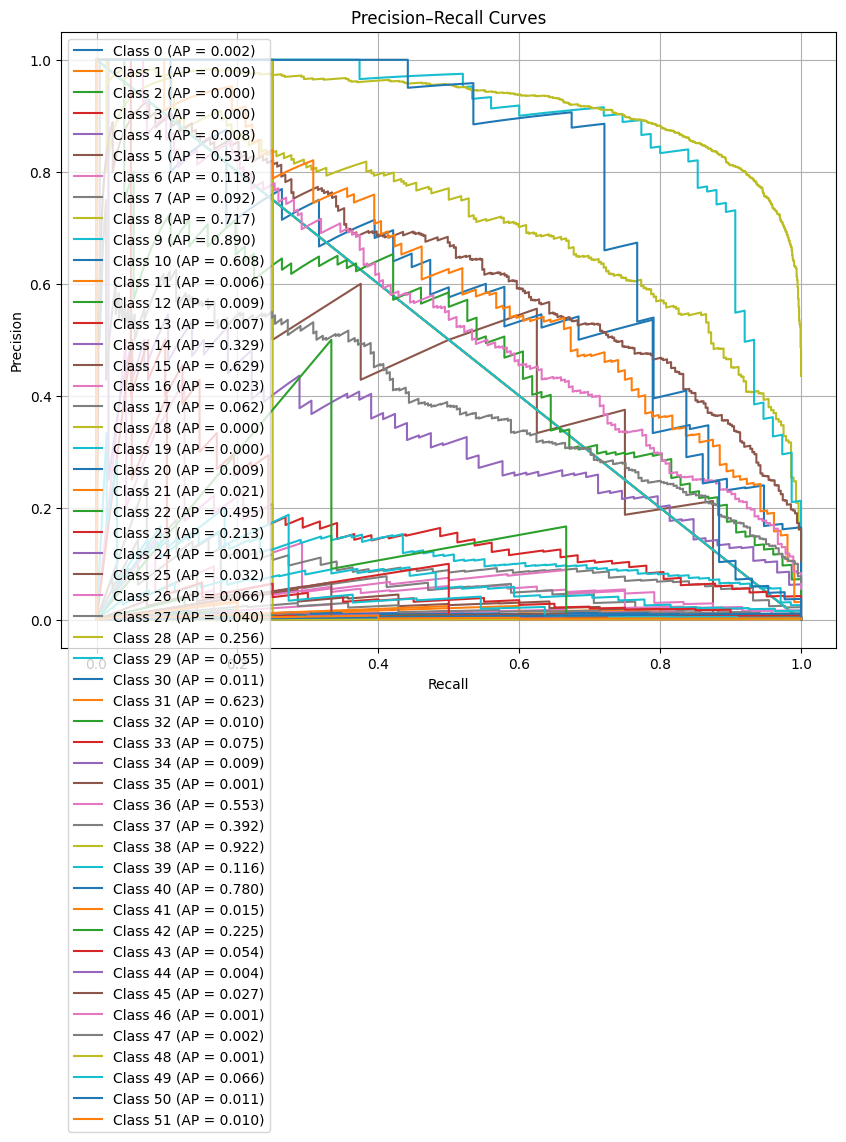

In [20]:
test_loss, test_acc = model.evaluate(X_test_short, y_test_cat, verbose=0)
print("\nTest Accuracy:", test_acc)

y_pred_prob = model.predict(X_test_short)
y_pred = np.argmax(y_pred_prob, axis=1)
y_test_labels = np.argmax(y_test_cat, axis=1)


cm = confusion_matrix(y_test_labels, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()


y_test_bin = label_binarize(y_test_labels, classes=np.arange(num_classes))

plt.figure(figsize=(10, 8))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()


plt.figure(figsize=(10, 8))

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_prob[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_pred_prob[:, i])
    plt.plot(recall, precision, label=f"Class {i} (AP = {ap:.3f})")

plt.title("Precision–Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid()
plt.show()